In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import json
import seaborn as sns

In [2]:
# Load data
# Download latest version
path = kagglehub.dataset_download("computingvictor/transactions-fraud-datasets")

print("Path to dataset files:", path)
# Load CSV files
card_data = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/cards_data.csv")
transactions = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/transactions_data.csv")
users_data = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/users_data.csv")
# Load Json files
with open("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/mcc_codes.json", "r") as f:
    mcc_codes = json.load(f)
with open("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/train_fraud_labels.json", "r") as f:
    train_fraud_labels = json.load(f)


Path to dataset files: /Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1


In [3]:
labels_dict = train_fraud_labels["target"] # Extract the dictionary from JSON
# Map the label using dictionary to transactions data
transactions["label"] = transactions["id"].astype(str).map(labels_dict)
# Test set: where 'label' is NaN
test_set = transactions[transactions['label'].isna()].copy()

# Training set: where 'label' is NOT NaN
train_set = transactions[transactions['label'].notna()].copy()


print('percentage of test: ', round(test_set.shape[0] / (train_set.shape[0] + train_set.shape[0]), 4))

# Display the counts
print(f"Training Set: {train_set.shape[0]} rows")
print(f"Test Set: {test_set.shape[0]} rows")

percentage of test:  0.2463
Training Set: 8914963 rows
Test Set: 4390952 rows


In [4]:
print(train_set.head())

        id                 date  client_id  card_id   amount  \
0  7475327  2010-01-01 00:01:00       1556     2972  $-77.00   
1  7475328  2010-01-01 00:02:00        561     4575   $14.57   
2  7475329  2010-01-01 00:02:00       1129      102   $80.00   
4  7475332  2010-01-01 00:06:00        848     3915   $46.41   
5  7475333  2010-01-01 00:07:00       1807      165    $4.81   

            use_chip  merchant_id merchant_city merchant_state      zip   mcc  \
0  Swipe Transaction        59935        Beulah             ND  58523.0  5499   
1  Swipe Transaction        67570    Bettendorf             IA  52722.0  5311   
2  Swipe Transaction        27092         Vista             CA  92084.0  4829   
4  Swipe Transaction        13051       Harwood             MD  20776.0  5813   
5  Swipe Transaction        20519         Bronx             NY  10464.0  5942   

  errors label  
0    NaN    No  
1    NaN    No  
2    NaN    No  
4    NaN    No  
5    NaN    No  


In [5]:
# Group by 'card_id' and count the number of transactions
card_transaction_counts = train_set.groupby('card_id').size().reset_index(name='transaction_count')

# Group by 'card_id' and count the number of 'Yes' labels (anomalies)
card_label_anomalies = train_set[train_set['label'] == 'Yes'].groupby('card_id').size().reset_index(name='label_anormality_count')

# Merge the two DataFrames on 'card_id'
card_transaction_counts = pd.merge(
    card_transaction_counts, 
    card_label_anomalies, 
    on='card_id', 
    how='left'
)

# Fill NaN values in 'label_anormality_count' with 0 (no anomalies for those cards)
card_transaction_counts['label_anormality_count'] = card_transaction_counts['label_anormality_count'].fillna(0).astype(int)

# Sort by transaction count / label_anormality count
card_transaction_counts = card_transaction_counts.sort_values(by='transaction_count', ascending=False).reset_index(drop=True)
card_anormal_transaction_counts = card_transaction_counts.sort_values(by='label_anormality_count', ascending=False).reset_index(drop=True)

# Display the result
print(card_transaction_counts.head())  # Display top cards
print(card_anormal_transaction_counts.head())  # Display top anormal cards
print(card_transaction_counts.tail(10))  # Display bottom cards

   card_id  transaction_count  label_anormality_count
0     4938              21307                       0
1     3239              20484                       7
2     2408              20448                       1
3     3233              18456                       3
4     3801              17052                       7
   card_id  transaction_count  label_anormality_count
0     3952               1450                      37
1     3697                465                      34
2      258                987                      29
3     2515               5061                      29
4     5860               2391                      28
      card_id  transaction_count  label_anormality_count
4060     4377                 15                       0
4061     5342                 15                       0
4062     4921                 13                       0
4063     4073                 12                       0
4064     4923                 11                       0
4065     6

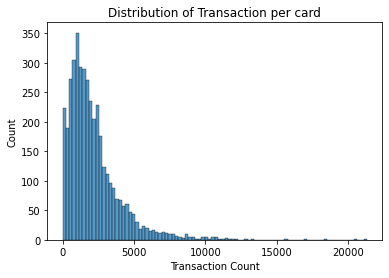

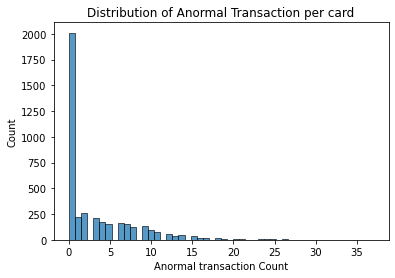

In [6]:
sns.histplot(data = card_transaction_counts, x = 'transaction_count', multiple = 'layer')
plt.xlabel("Transaction Count")
plt.ylabel("Count")
plt.title("Distribution of Transaction per card")
plt.show()

sns.histplot(data = card_transaction_counts, x = 'label_anormality_count', multiple = 'layer')
plt.xlabel("Anormal transaction Count")
plt.ylabel("Count")
plt.title("Distribution of Anormal Transaction per card")
plt.show()

Transaction Data Engineer
1. Using a moving average to benchmark transactions for anomaly detection
    a) fix sliding window
        i) transaction-based: low frequency - 10, high frequency
        ii) time-based: 
    b) 

In [7]:
train_set['amount'] = train_set['amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)
train_set['date'] = pd.to_datetime(train_set['date'])

In [8]:
train_set.dtypes

id                         int64
date              datetime64[ns]
client_id                  int64
card_id                    int64
amount                   float64
use_chip                  object
merchant_id                int64
merchant_city             object
merchant_state            object
zip                      float64
mcc                        int64
errors                    object
label                     object
dtype: object

In [9]:
# Sort by mcc and date for correct moving window calculation
train_set_transformed = train_set.copy().sort_values(by=['mcc', 'date'])

# Define a custom moving window parameter
moving_window = 10 # Customize this parameter as needed
ema_span = 5  # Customize EMA sensitivity

# Calculate moving average and moving standard deviation per mcc
train_set_transformed['moving_mean'] = train_set_transformed.groupby('mcc')['amount'].transform(lambda x: x.rolling(window=moving_window, min_periods=1).mean())
train_set_transformed['moving_std'] = train_set_transformed.groupby('mcc')['amount'].transform(lambda x: x.rolling(window=moving_window, min_periods=1).std(ddof=0))

# Calculate exponential moving average (EMA)
train_set_transformed['ema'] = train_set_transformed.groupby('mcc')['amount'].transform(
    lambda x: x.ewm(span=ema_span, adjust=False).mean()
)

# Centralized and standardized transactions
train_set_transformed['centralized_transaction'] = train_set_transformed['amount'] - train_set_transformed['moving_mean']
train_set_transformed['standardized_transaction'] = train_set_transformed['centralized_transaction'] / train_set_transformed['moving_std'].replace(0, 1)  # Avoid division by zero

# Display the result
pd.set_option('display.float_format', lambda x: '%.2f' % x)  # Format floats for better readability
print(train_set_transformed.head())

            id                date  client_id  card_id  amount  \
5404   7481765 2010-01-02 15:12:00        447     3865   73.07   
8264   7485203 2010-01-03 13:13:00        773     2570   73.73   
9150   7486268 2010-01-03 17:32:00       1518     2584  250.70   
21388  7500990 2010-01-07 12:48:00       1515     5557  134.74   
21395  7501002 2010-01-07 12:50:00       1515     5557  129.92   

                use_chip  merchant_id merchant_city merchant_state      zip  \
5404   Swipe Transaction        79439      Muskegon             MI 49441.00   
8264   Swipe Transaction        32107    Rainsville             AL 35986.00   
9150   Swipe Transaction        36214    Somerville             AL 35670.00   
21388  Swipe Transaction        55134       Lebanon             PA 17042.00   
21395  Swipe Transaction        55134       Lebanon             PA 17042.00   

        mcc                errors label  moving_mean  moving_std    ema  \
5404   1711                   NaN    No        73.07 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_card_transaction_simple(transactions, card_id, amount_col="amount"):
    """
    Plots an engineered transaction feature over time for a specific card ID.

    Parameters:
    transactions (pd.DataFrame): The transaction dataset.
    card_id (int or str): The card ID to filter.
    amount_col (str): The column name for the value to be plotted (e.g., "amount", "ema", "moving_mean").

    Returns:
    None (Displays a plot)
    """

    # Filter transactions for the specific card
    card_data = transactions[transactions["card_id"] == card_id].copy()

    # Check if any data exists
    if card_data.empty:
        print(f"No transactions found for Card ID {card_id}.")
        return

    # Convert 'date' to datetime format
    card_data["date"] = pd.to_datetime(card_data["date"])

    # Check if the requested column exists
    if amount_col not in card_data.columns:
        print(f"Column '{amount_col}' not found in the dataset.")
        return

    # Drop missing or zero values in the selected column
    card_data = card_data.dropna(subset=[amount_col])
    if card_data[amount_col].sum() == 0:
        print(f"All values for '{amount_col}' in Card ID {card_id} are zero.")
        return

    # Sort by date
    card_data = card_data.sort_values(by="date")

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(card_data["date"], card_data[amount_col], marker='o', linestyle='-', markersize=5, alpha=0.8)

    # Title and labels
    plt.title(f"{amount_col} Over Time for Card ID {card_id}")
    plt.xlabel("Date")
    plt.ylabel(amount_col.replace("_", " ").title())  # Format label
    plt.grid(True)

    # Show plot
    plt.show()


      card_id  transaction_count  label_anormality_count
4065     6107                 10                       0
4066     2814                 10                       0
4067      314                  7                       2
4068     5344                  4                       0
4069     5339                  2                       0
[6107, 2814, 314, 5344, 5339]


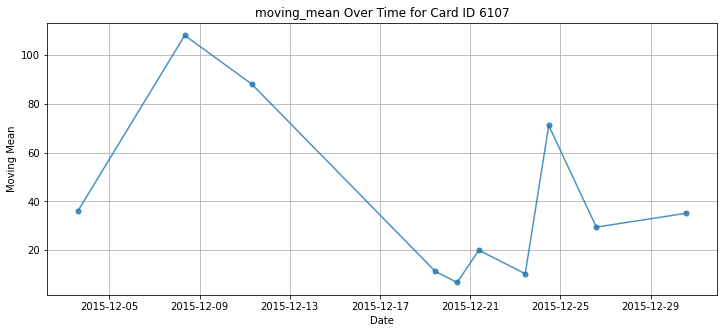

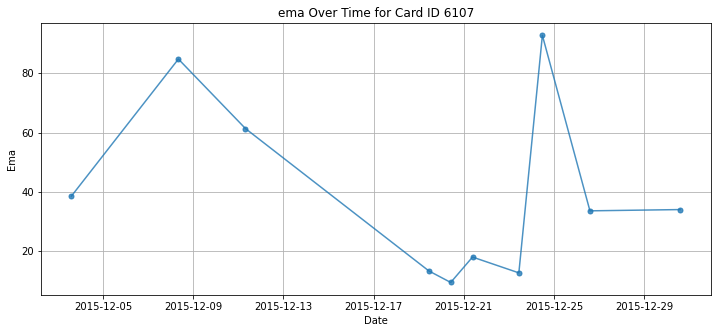

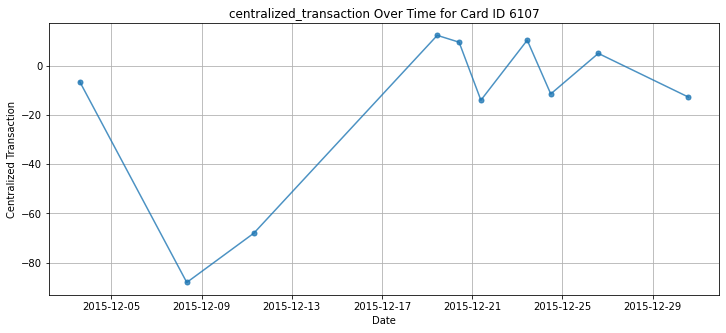

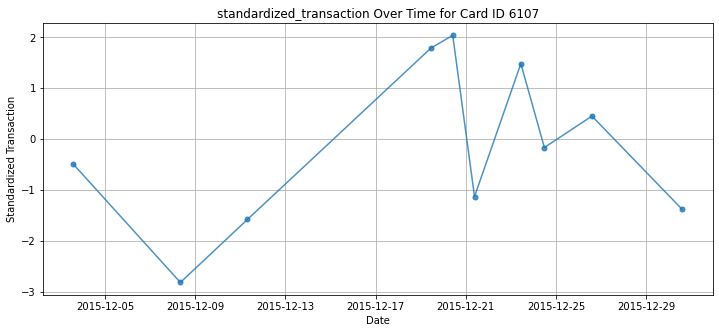

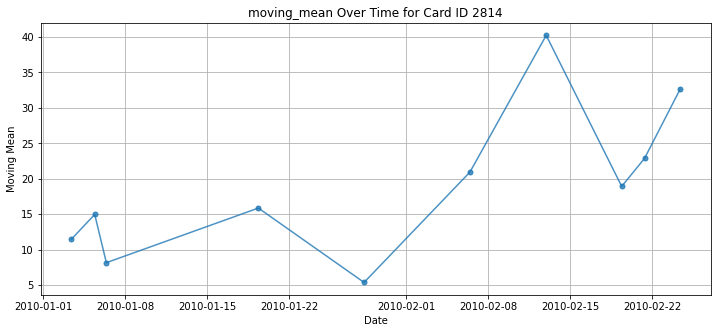

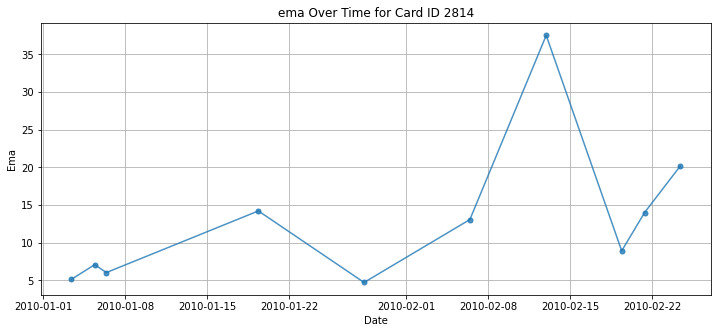

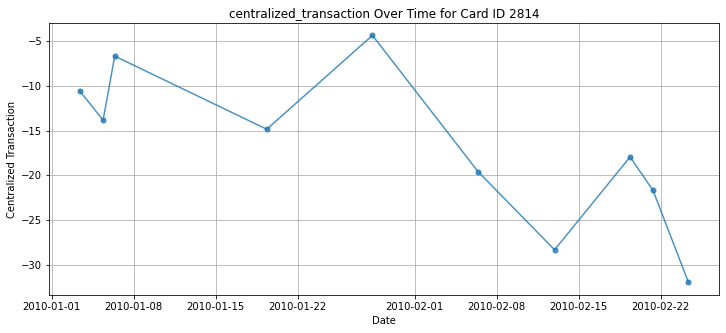

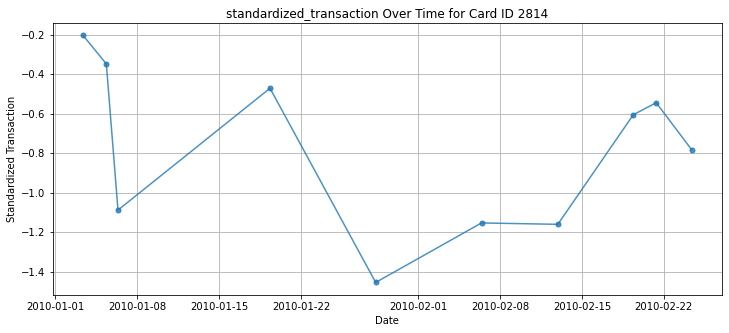

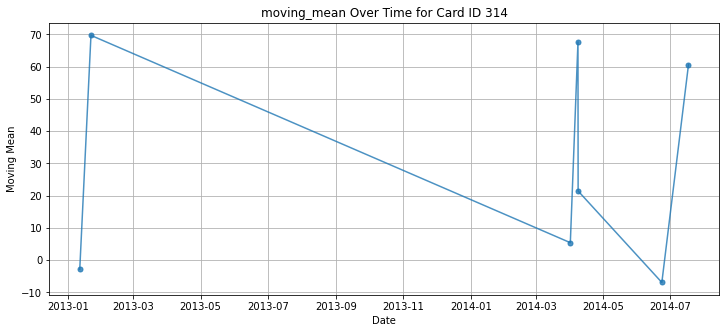

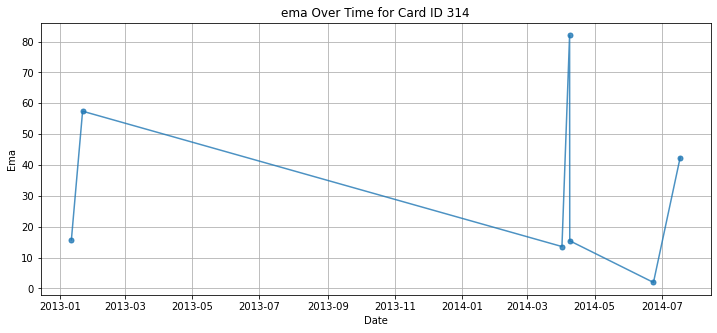

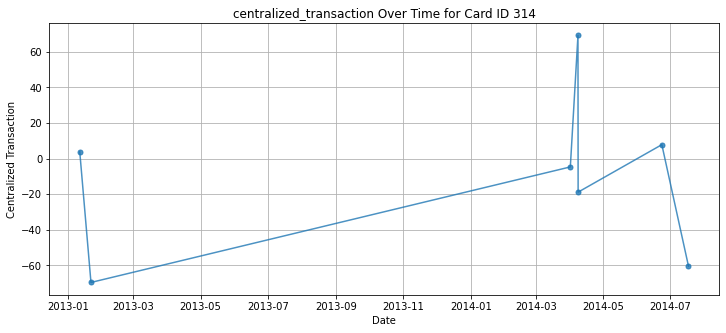

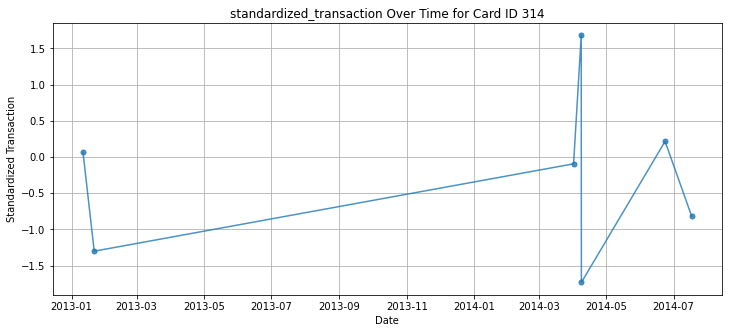

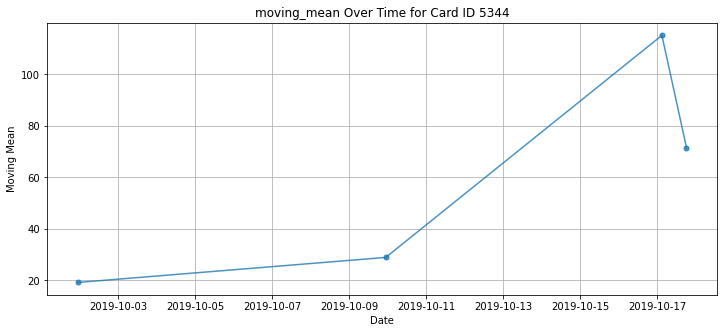

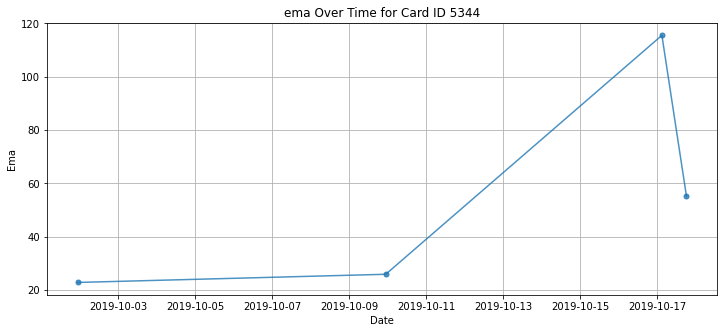

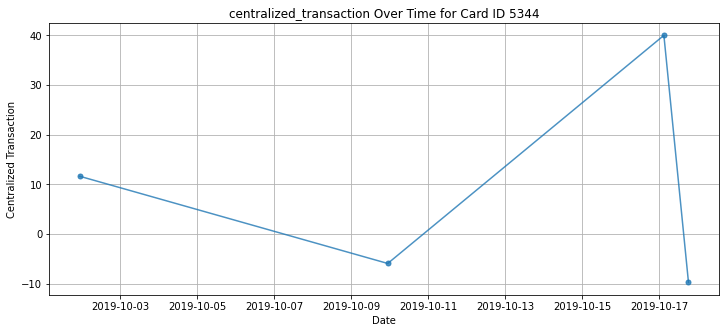

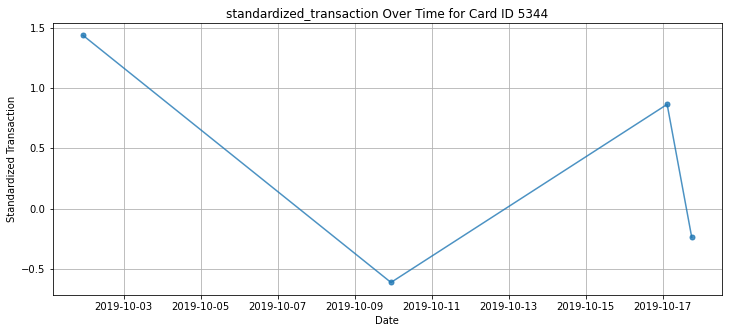

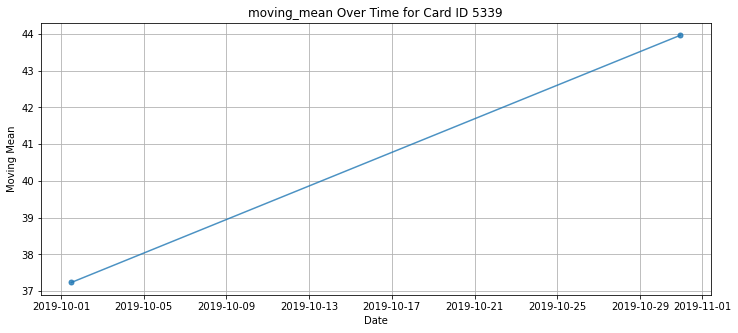

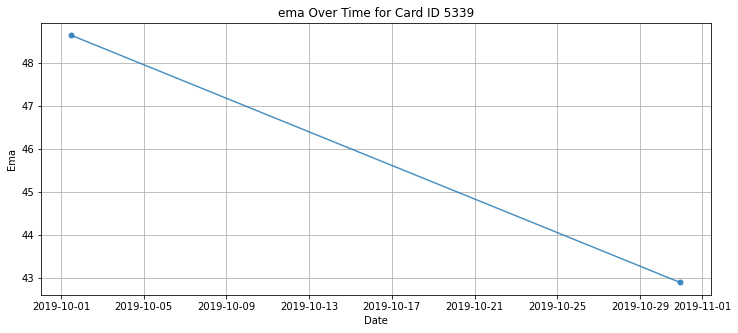

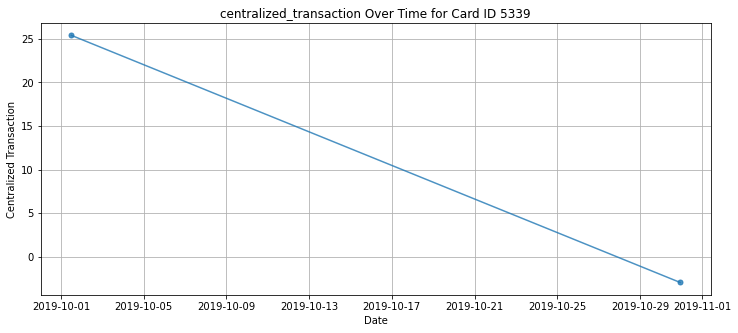

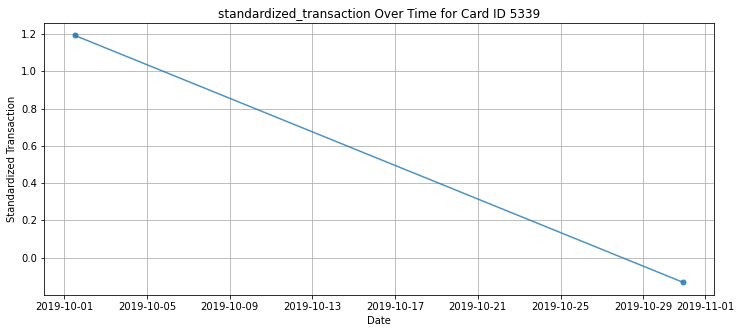

In [11]:
# Examples
engineered_transactions = ["moving_mean", "ema", "centralized_transaction", "standardized_transaction"]
print(card_transaction_counts.tail())  # Display bottom cards
least_transaction_cards = list(card_transaction_counts.tail()['card_id'])
print(least_transaction_cards)
for card_id in least_transaction_cards:
    for amount_col in engineered_transactions:
        plot_card_transaction_simple(train_set_transformed, card_id, amount_col=amount_col)

   card_id  transaction_count  label_anormality_count
0     3952               1450                      37
1     3697                465                      34
2      258                987                      29
3     2515               5061                      29
4     5860               2391                      28
[3952, 3697, 258, 2515, 5860]


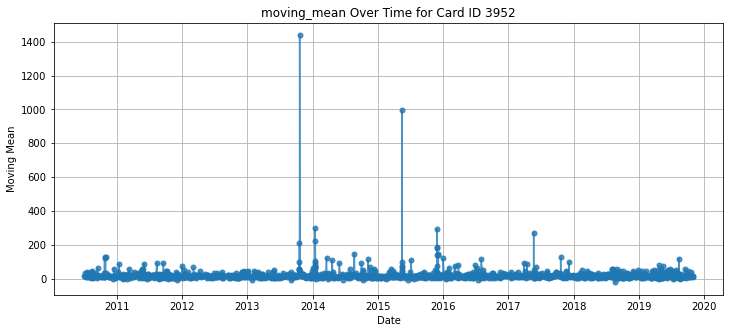

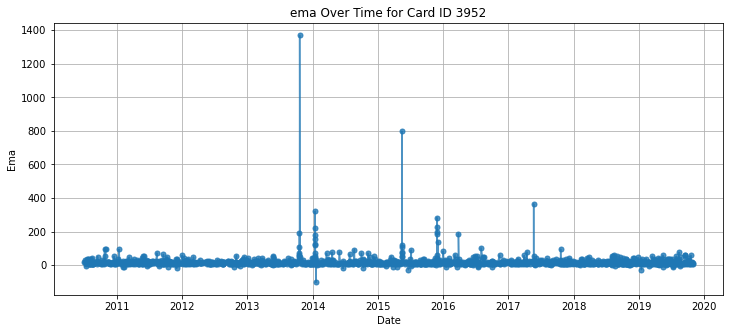

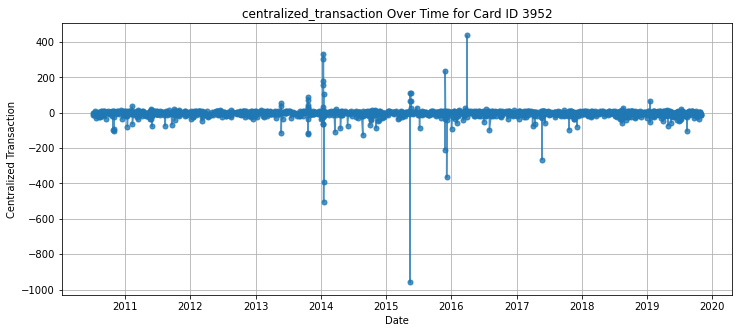

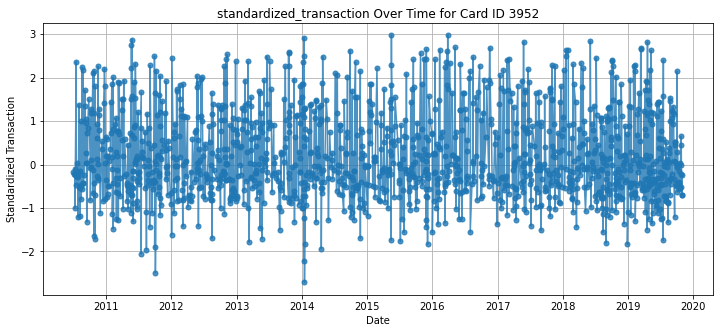

In [12]:
print(card_anormal_transaction_counts.head())  # Display top anormal cards
engineered_transactions = ["moving_mean", "ema", "centralized_transaction", "standardized_transaction"]
most_anormal_transaction_cards = list(card_anormal_transaction_counts.head()['card_id'])
print(most_anormal_transaction_cards)
card_id = most_anormal_transaction_cards[0]
for amount_col in engineered_transactions:
    plot_card_transaction_simple(train_set_transformed, card_id, amount_col=amount_col)

In [ ]:
# Detect anomalies - standard statistical methods
def detect_anomalies_zscore(df, threshold=1.5):
    df["anomaly_zscore"] = (df["standardized_transaction"].abs() > threshold)
    return df

def detect_anomalies_mad(df, threshold=4):
    median = df["centralized_transaction"].median()
    mad = np.median(np.abs(df["centralized_transaction"] - median))
    df["mad_score"] = 0.6745 * (df["centralized_transaction"] - median) / (mad + 1e-9)
    df["anomaly_mad"] = df["mad_score"].abs() > threshold
    return df

In [25]:
# Detect anomalies - time series methods
def detect_anomalies_iqr(df, window=10):
    q1 = df["moving_mean"].rolling(window).quantile(0.25)
    q3 = df["moving_mean"].rolling(window).quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 2 * iqr
    upper_bound = q3 + 2 * iqr
    df["anomaly_iqr"] = (df["moving_mean"] < lower_bound) | (df["moving_mean"] > upper_bound)
    return df

def detect_anomalies_ema(df, threshold=1.5):
    df["ema_deviation"] = np.abs(df["centralized_transaction"]) / (df["ema"] + 1e-9)
    df["anomaly_ema"] = df["ema_deviation"] > threshold
    return df


In [15]:
# Detect anormalies - ML methods 

# For large scale data
from sklearn.ensemble import IsolationForest
def detect_anomalies_isolation_forest(df, contamination=0.01):
    model = IsolationForest(contamination=contamination, random_state=42)
    df["anomaly_iforest"] = model.fit_predict(df[["moving_mean", "ema", "centralized_transaction", "standardized_transaction"]])
    df["anomaly_iforest"] = df["anomaly_iforest"] == -1  # -1 means anomaly
    return df

# For complex patterns 
from sklearn.svm import OneClassSVM
def detect_anomalies_svm(df, nu=0.01):
    model = OneClassSVM(kernel="rbf", nu=nu)
    df["anomaly_svm"] = model.fit_predict(df[["moving_mean", "ema", "centralized_transaction", "standardized_transaction"]])
    df["anomaly_svm"] = df["anomaly_svm"] == -1  # -1 means anomaly
    return df


In [30]:
from sklearn.neighbors import LocalOutlierFactor

def detect_anomalies_lof(df, n_neighbors=20, contamination=0.01):
    """
    Detects anomalies using Local Outlier Factor (LOF).

    Parameters:
    df (pd.DataFrame): The dataset containing engineered transaction features.
    n_neighbors (int): Number of neighbors to compare local density (default=20).
    contamination (float): Expected proportion of anomalies (default=0.01, or 1%).

    Returns:
    pd.DataFrame: The updated DataFrame with an 'anomaly_lof' column (True for anomaly, False otherwise).
    """

    # Select features for anomaly detection
    features = ["moving_mean", "ema", "centralized_transaction", "standardized_transaction"]

    # Check if all required columns exist
    for feature in features:
        if feature not in df.columns:
            raise ValueError(f"Column '{feature}' not found in the dataset. Please compute it first.")

    # Initialize LOF model
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)

    # Fit LOF and get anomaly predictions (-1 = anomaly, 1 = normal)
    df["anomaly_lof"] = lof.fit_predict(df[features])
    
    # Convert LOF results to binary (1 for anomaly, 0 for normal)
    df["anomaly_lof"] = df["anomaly_lof"] == -1

    return df


In [26]:
zscore = detect_anomalies_zscore(train_set_transformed, threshold=3)
mad = detect_anomalies_mad(train_set_transformed, threshold=3.5)
print(zscore[['anomaly_zscore', 'label']])
print(mad[['anomaly_mad', 'label']])

          anomaly_zscore label
5404               False    No
8264               False    No
9150               False    No
21388              False    No
21395              False    No
...                  ...   ...
13304709           False    No
13304729           False    No
13304896           False    No
13304933           False    No
13305090           False    No

[8914963 rows x 2 columns]
          anomaly_mad label
5404            False    No
8264            False    No
9150             True    No
21388           False    No
21395           False    No
...               ...   ...
13304709        False    No
13304729        False    No
13304896        False    No
13304933        False    No
13305090        False    No

[8914963 rows x 2 columns]


In [27]:
moving_iqr = detect_anomalies_iqr(train_set_transformed, window=10)
ema = detect_anomalies_ema(train_set_transformed, threshold=2)
print(moving_iqr[['anomaly_iqr', 'label']])
print(ema[['anomaly_ema', 'label']])

          anomaly_iqr label
5404            False    No
8264            False    No
9150            False    No
21388           False    No
21395           False    No
...               ...   ...
13304709         True    No
13304729         True    No
13304896        False    No
13304933        False    No
13305090        False    No

[8914963 rows x 2 columns]
          anomaly_ema label
5404            False    No
8264            False    No
9150            False    No
21388           False    No
21395           False    No
...               ...   ...
13304709        False    No
13304729        False    No
13304896        False    No
13304933        False    No
13305090        False    No

[8914963 rows x 2 columns]


In [18]:
moving_iqr = detect_anomalies_iqr(train_set_transformed, window=10)
ema = detect_anomalies_ema(train_set_transformed, threshold=2)
print(moving_iqr[['anomaly_iqr', 'label']])
print(ema[['anomaly_ema', 'label']])

          anomaly_iqr label
5404            False    No
8264            False    No
9150            False    No
21388           False    No
21395           False    No
...               ...   ...
13304709         True    No
13304729         True    No
13304896        False    No
13304933        False    No
13305090        False    No

[8914963 rows x 2 columns]
          anomaly_ema label
5404            False    No
8264            False    No
9150            False    No
21388           False    No
21395           False    No
...               ...   ...
13304709        False    No
13304729        False    No
13304896        False    No
13304933        False    No
13305090        False    No

[8914963 rows x 2 columns]


In [33]:
isolation_forest = detect_anomalies_isolation_forest(train_set_transformed, contamination=0.01)
print(isolation_forest[['anomaly_iforest', 'label']])


          anomaly_iforest label
5404                False    No
8264                False    No
9150                False    No
21388               False    No
21395               False    No
...                   ...   ...
13304709            False    No
13304729            False    No
13304896            False    No
13304933            False    No
13305090            False    No

[8914963 rows x 2 columns]


In [ ]:
svm = detect_anomalies_svm(train_set_transformed, nu=0.01)
print(svm[['anomaly_svm', 'label']])

In [ ]:
lof = detect_anomalies_lof(train_set_transformed, n_neighbors=20, contamination=0.01)
# print(lof[['anomaly_lof', 'label']])

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_anomaly_detection(df, anomaly_col, label_col="label"):
    """
    Evaluates anomaly detection performance using precision, recall, and weighted F1 score.
    
    Parameters:
    df (pd.DataFrame): The dataset containing true labels and detected anomalies.
    anomaly_col (str): The column name where detected anomalies are stored (binary: 1 for anomaly, 0 for normal).
    label_col (str): The ground truth anomaly label column (binary: 1 for true anomaly, 0 for normal).
    
    Returns:
    dict: A dictionary containing precision, recall, and weighted F1 score.
    """
    
    # Ensure the columns exist
    if anomaly_col not in df.columns:
        raise ValueError(f"Column '{anomaly_col}' not found in the dataset.")
    if label_col not in df.columns:
        raise ValueError(f"Column '{label_col}' not found in the dataset.")
    
    # Convert to binary values (in case they are not already)
    label_mapping = {"Yes": 1, "No": 0}
    y_true = df[label_col].map(label_mapping) # True anomalies
    y_pred = df[anomaly_col].astype(int)  # Detected anomalies

    # Calculate metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    
    # Return results
    results = {
        "Precision": precision,
        "Recall": recall,
        "Weighted F1 Score": f1_weighted
    }
    
    return results


In [32]:
# Example: Evaluating 
results = evaluate_anomaly_detection(lof, anomaly_col="anomaly_lof")
print(results)

{'Precision': 0.003555804823331464, 'Recall': 0.02377737773777378, 'Weighted F1 Score': 0.9927771637837679}


In [34]:
results = evaluate_anomaly_detection(isolation_forest, anomaly_col="anomaly_iforest")
print(results)

{'Precision': 0.014402692091979809, 'Recall': 0.0963096309630963, 'Weighted F1 Score': 0.9929143188112812}


In [ ]:
results = evaluate_anomaly_detection(svm, anomaly_col="svm")
print(results)

In [28]:
methods = ["anomaly_zscore", "anomaly_mad", "anomaly_iqr", "anomaly_ema"] #, "anomaly_iforest", "anomaly_svm"
data = [zscore, mad, moving_iqr, ema] # , "isolation_forest", "svm"
for i in range(len(methods)):
    method = methods[i]
    results = evaluate_anomaly_detection(data[i], anomaly_col=method)
    print(f"Results for {method}: {results}")
    
# Very low precision (close to 0%) means most detected anomalies are false positives.
# Low recall (except for anomaly_mad) means many true anomalies are missed.
# Weighted F1 Score is high because the dataset is highly imbalanced (very few anomalies vs. many normal transactions).

Results for anomaly_zscore: {'Precision': 0.0, 'Recall': 0.0, 'Weighted F1 Score': 0.997757364568866}
Results for anomaly_mad: {'Precision': 0.006822251442088501, 'Recall': 0.3097809780978098, 'Weighted F1 Score': 0.9631097530783728}
Results for anomaly_iqr: {'Precision': 0.003431338285474637, 'Recall': 0.12151215121512152, 'Weighted F1 Score': 0.9707541000081081}
Results for anomaly_ema: {'Precision': 0.0015636322702744536, 'Recall': 0.06668166816681668, 'Weighted F1 Score': 0.9649264918104319}
